In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# load dataset to notebook
ventures = pd.read_csv('Data/ventures.csv')
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,trend_slope,news_volume,news_sentiment,reddit_density,gdp_growth,inflation,startup_density
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,-0.074907,223401,6.1121,3.9247,2.289113,2.069337,8.1759
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,-0.074907,223401,6.1121,3.9247,3.672019,3.933400,4.5362
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,0.095247,289042,2.8252,0.0000,2.523820,1.622223,2.2114
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,-0.090973,149705,6.5582,13.4627,2.695193,1.640043,6.9430
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,0.207265,223401,6.1121,4.2757,6.155340,3.007448,2.7399


In [3]:
ventures.info()

<class 'pandas.DataFrame'>
RangeIndex: 25539 entries, 0 to 25538
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  25539 non-null  str    
 1   industry              25539 non-null  str    
 2   category              25539 non-null  str    
 3   founded_year          25539 non-null  int64  
 4   country               25539 non-null  str    
 5   status                25539 non-null  str    
 6   funding_total_usd     25539 non-null  int64  
 7   funding_rounds        25539 non-null  int64  
 8   opportunity_score     25539 non-null  float64
 9   opportunity_category  25539 non-null  str    
 10  trend_slope           25539 non-null  float64
 11  news_volume           25539 non-null  int64  
 12  news_sentiment        25539 non-null  float64
 13  reddit_density        25539 non-null  float64
 14  gdp_growth            25133 non-null  float64
 15  inflation             25018 no

In [4]:
ventures.dtypes

name                        str
industry                    str
category                    str
founded_year              int64
country                     str
status                      str
funding_total_usd         int64
funding_rounds            int64
opportunity_score       float64
opportunity_category        str
trend_slope             float64
news_volume               int64
news_sentiment          float64
reddit_density          float64
gdp_growth              float64
inflation               float64
startup_density         float64
dtype: object

In [5]:
ventures.isnull().sum()

name                      0
industry                  0
category                  0
founded_year              0
country                   0
status                    0
funding_total_usd         0
funding_rounds            0
opportunity_score         0
opportunity_category      0
trend_slope               0
news_volume               0
news_sentiment            0
reddit_density            0
gdp_growth              406
inflation               521
startup_density         403
dtype: int64

In [6]:
# summary statistics
ventures.describe()

,founded_year,funding_total_usd,funding_rounds,opportunity_score,trend_slope,news_volume,news_sentiment,reddit_density,gdp_growth,inflation,startup_density
count,25539.000000,2.553900e+04,25539.000000,25539.000000,25539.000000,25539.000000,25539.000000,25539.000000,25133.000000,25018.000000,25136.000000
mean,2009.946709,9.995820e+06,1.827480,51.109114,-0.030594,154897.474412,5.817192,6.235268,1.899344,2.482737,4.790739
std,2.476410,5.133717e+07,1.345131,6.147572,0.096504,76281.270817,1.313387,20.322064,2.469926,1.836669,2.841720
min,2005.000000,0.000000e+00,1.000000,29.110000,-0.231172,9041.000000,-1.326800,0.000000,-16.040020,-4.447547,0.003000
25%,2008.000000,7.500000e+04,1.000000,47.760000,-0.090973,83586.000000,6.112100,0.107000,1.564407,1.622223,2.424700
50%,2010.000000,9.300000e+05,1.000000,51.630000,-0.055052,149705.000000,6.415900,0.710000,2.117830,2.138384,5.092400
75%,2012.000000,5.000000e+06,2.000000,54.340000,0.014353,218815.000000,6.558200,4.275700,2.695193,3.156842,6.943000
max,2020.000000,2.600000e+09,18.000000,75.720000,0.364155,989564.000000,6.592600,280.337400,14.519750,53.228698,60.378000


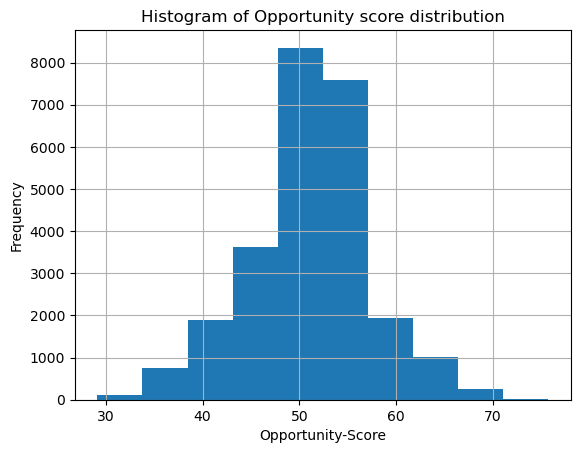

In [7]:
# opportunity score histogram to check distribution

ventures['opportunity_score'].hist(bins=10)
plt.title('Histogram of Opportunity score distribution')
plt.xlabel('Opportunity-Score')
plt.ylabel('Frequency')
plt.show()

In [8]:
# correlation
numeric_cols = ventures.select_dtypes(include='number').columns.tolist()
corr = ventures[numeric_cols].corr()['opportunity_score'].drop('opportunity_score').sort_values(key=abs, ascending=False)
print(corr.to_string())

trend_slope          0.585853
news_sentiment       0.411761
funding_rounds       0.273959
founded_year        -0.250663
news_volume         -0.204278
funding_total_usd    0.145830
reddit_density       0.126315
gdp_growth           0.124918
inflation            0.093542
startup_density      0.047716


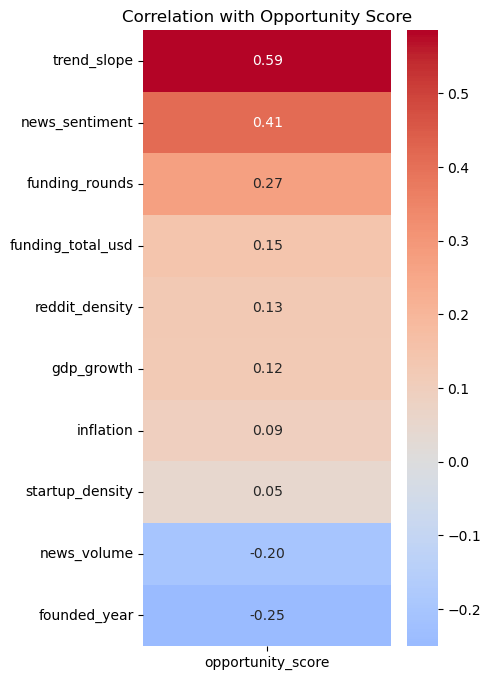

In [9]:
# correlation of all numeric columns with opportunity_score
target_corr = ventures.select_dtypes(include='number').corr()[['opportunity_score']]

# excluding the self-correlation of 1.0
target_corr = target_corr.drop(index='opportunity_score').sort_values(by='opportunity_score', ascending=False)

# plot
plt.figure(figsize=(4, 8)) # display single column
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.title('Correlation with Opportunity Score')
plt.show()

In [10]:
# group by category and calculate mean opportunity score
category_analysis = ventures.groupby('category')['opportunity_score'].mean().sort_values(ascending=False)

# displaying the results
print(category_analysis)

category
Gaming                            58.333182
E-Commerce & Retail               57.405429
Customer Service & CRM            55.430932
Data & Analytics                  55.134185
Finance & Fintech                 54.663532
Social & Community                54.368954
Marketing & Advertising           53.731381
AI & Machine Learning             52.556951
Travel & Hospitality              51.935708
Food & Beverage                   51.774186
Education & Training              50.997955
Technology & Software             50.712782
Communications & Telecom          50.046423
Energy & Clean Tech               49.426561
Healthcare & Life Sciences        49.394659
Manufacturing & Industrial        49.386926
Government & Politics             49.386444
Media & Entertainment             49.347271
Sports & Recreation               49.185740
Transportation & Logistics        48.943600
Internet & Web Services           48.206515
Security & Privacy                48.201629
HR & Recruiting        

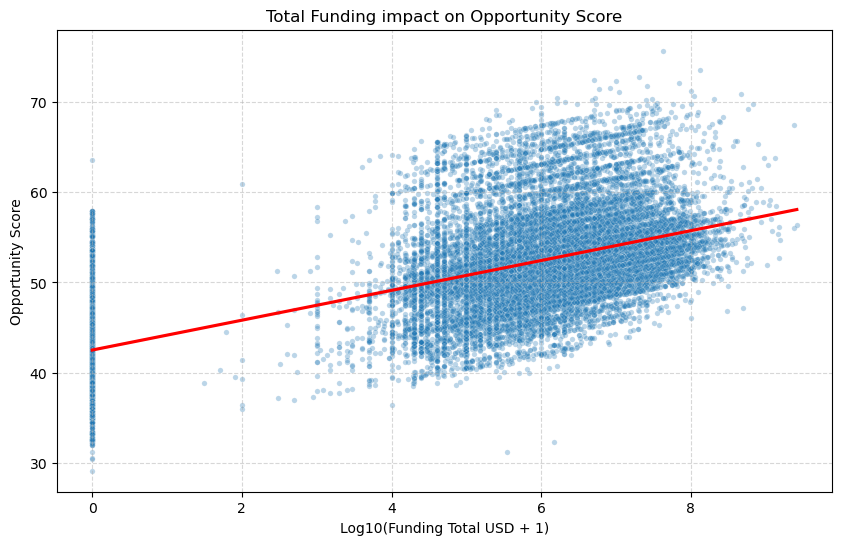

In [11]:
# handle $0 by applying log10(x+1)
ventures['log_funding'] = np.log10(ventures['funding_total_usd'] + 1)
# scatter plot with regression trend line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ventures, x='log_funding', y='opportunity_score', alpha=0.3, s=15)
sns.regplot(data=ventures, x='log_funding', y='opportunity_score', scatter=False, color='red')

plt.title('Total Funding impact on Opportunity Score')
plt.xlabel('Log10(Funding Total USD + 1)')
plt.ylabel('Opportunity Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **FINDINGS FROM ABOVE PLOT**
- The "Zero-Funding" Cluster: A vertical line of points at $0$ on the x-axis represents the 15% of startups with no funding. Their scores are widely distributed, suggesting that for many startups, "opportunity" is driven by factors other than capital (like news sentiment or trend slope).
- Correlation Trend: The red regression line shows the general relationship. If it slopes upward, it indicates that higher funding generally correlates with a higher opportunity_score, though the "spread" (variance) shows it is far from the only factor.
- Diminishing Returns: By using a log scale, we can see if the jump from 1 million to 10 million has a similar impact on the score as the jump from 10 million to 100 million.

In [12]:
# drop null values in dataset
ventures = ventures.dropna()
ventures.isnull().sum()

name                    0
industry                0
category                0
founded_year            0
country                 0
status                  0
funding_total_usd       0
funding_rounds          0
opportunity_score       0
opportunity_category    0
trend_slope             0
news_volume             0
news_sentiment          0
reddit_density          0
gdp_growth              0
inflation               0
startup_density         0
log_funding             0
dtype: int64

# **FEATURE ENGINEERING**

To transform the 7 raw numeric features into a robust predictive engine, we expanded the dataset to **89 features**. This process follows a hierarchical approach to capture non-linearities, interactions, and domain-specific insights.

#### **1. Handling Skewness & Scale (Log & Z-Scores)**

* **Why:** Financial and social data (funding, news volume) are typically "long-tailed"—a few startups have billions in funding while most have very little.
* **Action:** Applied `np.log1p` to `funding`, `news_volume`, and `reddit_density` to normalize distributions. We also calculated **Z-Scores** for primary signals to ensure all features share a common mean () and standard deviation (), preventing the model from being biased toward large raw numbers.

#### **2. Capturing Non-Linearity (Polynomials & Ratios)**

* **Why:** The relationship between a feature and the `opportunity_score` isn't always a straight line. For example, extreme GDP growth (boom) or contraction (recession) might impact opportunity more than moderate growth.
* **Action:** Created squared terms (`trend_slope_sq`, `gdp_growth_sq`) and square roots (`funding_sqrt`). We introduced **Ratios** like `funding_per_round` to measure capital efficiency.

#### **3. Interaction & Derived Features**

* **Why:** Features often "talk" to each other. High `news_volume` is a positive signal only if `news_sentiment` is also high.
* **Action:** Created interaction terms (e.g., `news_x_sentiment`) and the `econ_health` metric (GDP Growth - Inflation) to serve as a proxy for real-world economic stability.

#### **4. Categorical Encoding & Dimensionality Management**

* **Why:** ML models cannot read text. However, encoding 103 countries would create too much "noise" (The Curse of Dimensionality).
* **Action:** * **One-Hot Encoding:** Applied to `category` (26 sectors) and `status`.
* **Frequency Grouping:** For `country`, we flagged the top 10 (including the **UK** and US) and grouped the remaining 93 into an "Other" category to keep the model lean.



#### **5. Domain-Specific Binning (Funding Tiers)**

* **Why:** To capture the qualitative "stage" of a company.
* **Action:** Segmented startups into `unfunded`, `seed`, `series_a`, and `series_b_plus`. This helps the model distinguish between the risk profiles of a bootstrapped startup versus a venture-backed scale-up.

#### **6. Temporal Features (Vintage Analysis)**

* **Why:** Older companies (higher `company_age`) have different survival signals than brand-new ones.
* **Action:** Calculated age relative to 2020 and created binary flags for specific eras (`pre_2010` for crisis survivors and `post_2015` for the modern tech wave).


**Summary of Final Dataset:**

* **Original Columns:** 17
* **Final Feature Count:** 89
* **Integrity:** 0 null values, outliers capped at 1st/99th percentiles.

In [13]:
# Log transformations
# normalization of right_skewed data and handling zero values
ventures['funding_log'] = np.log1p(ventures['funding_total_usd'])
ventures['news_volume_log'] = np.log1p(ventures['news_volume'])
ventures['reddit_density_log'] = np.log1p(ventures['reddit_density'])
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,news_volume,news_sentiment,reddit_density,gdp_growth,inflation,startup_density,log_funding,funding_log,news_volume_log,reddit_density_log
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,223401,6.1121,3.9247,2.289113,2.069337,8.1759,6.243038,14.375127,12.316728,1.594263
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,223401,6.1121,3.9247,3.672019,3.933400,4.5362,4.602071,10.596660,12.316728,1.594263
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,289042,2.8252,0.0000,2.523820,1.622223,2.2114,4.778158,11.002117,12.574331,0.000000
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,149705,6.5582,13.4627,2.695193,1.640043,6.9430,0.000000,0.000000,11.916429,2.671573
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,223401,6.1121,4.2757,6.155340,3.007448,2.7399,4.602071,10.596660,12.316728,1.663111


In [14]:
# polynomial features
# squared features for trend_slope (amplifies impact of strong positive/negative trends)
ventures['trend_slope_sq'] = ventures['trend_slope'] ** 2
# square feature for gdp_growth (highlights extreme economic conditions)
ventures['gdp_growth_sq'] = ventures['gdp_growth'] ** 2
#  square root of funding (provides a scale between the raw values and the log transform)
ventures['funding_sqrt'] = np.sqrt(ventures['funding_total_usd'])
# Preview the relationships
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,gdp_growth,inflation,startup_density,log_funding,funding_log,news_volume_log,reddit_density_log,trend_slope_sq,gdp_growth_sq,funding_sqrt
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,2.289113,2.069337,8.1759,6.243038,14.375127,12.316728,1.594263,0.005611,5.240040,1322.875656
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,3.672019,3.933400,4.5362,4.602071,10.596660,12.316728,1.594263,0.005611,13.483722,200.000000
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,2.523820,1.622223,2.2114,4.778158,11.002117,12.574331,0.000000,0.009072,6.369666,244.948974
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,2.695193,1.640043,6.9430,0.000000,0.000000,11.916429,2.671573,0.008276,7.264063,0.000000
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,6.155340,3.007448,2.7399,4.602071,10.596660,12.316728,1.663111,0.042959,37.888211,200.000000


In [15]:
# interaction features (combining signals)
ventures['trend_x_gdp'] = ventures['trend_slope'] * ventures['gdp_growth']
ventures['trend_x_sentiment'] = ventures['trend_slope'] * ventures['news_sentiment']
ventures['reddit_x_sentiment'] = ventures['reddit_density'] * ventures['news_sentiment']
ventures['funding_x_rounds'] = ventures['funding_log'] * ventures['funding_rounds']
ventures['trend_x_reddit'] = ventures['trend_slope'] * ventures["reddit_density_log"]
ventures['gdp_x_density'] = ventures['gdp_growth'] * ventures['startup_density']
ventures['news_x_sentiment'] = ventures['news_volume_log'] * ventures['news_sentiment']
# create economic feature that represents "real_growth" by adjusting gdp for inflation
ventures['econ_health'] = ventures['gdp_growth'] - ventures['inflation']
# preview new features
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,gdp_growth_sq,funding_sqrt,trend_x_gdp,trend_x_sentiment,reddit_x_sentiment,funding_x_rounds,trend_x_reddit,gdp_x_density,news_x_sentiment,econ_health
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,5.240040,1322.875656,-0.171471,-0.457841,23.988159,14.375127,-0.119422,18.715562,75.281074,0.219776
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,13.483722,200.000000,-0.275061,-0.457841,23.988159,10.596660,-0.119422,16.657011,75.281074,-0.261381
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,6.369666,244.948974,0.240386,0.269091,0.000000,22.004233,0.000000,5.581175,35.524999,0.901597
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,7.264063,0.000000,-0.245190,-0.596621,88.291079,0.000000,-0.243042,18.712722,78.150322,1.055149
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,37.888211,200.000000,1.275786,1.266824,26.133506,10.596660,0.344705,16.865016,75.281074,3.147892


In [16]:
# ratio features
ventures['funding_per_round'] = ventures['funding_total_usd'] / (ventures['funding_rounds'] + 1)
ventures['real_gdp_growth'] = ventures['gdp_growth'] / (1+ventures['inflation'] / 100)
ventures['investment_climate'] = ventures['gdp_growth'] / (ventures['inflation'] + 1)
ventures['ecosystem_strength'] = ventures['startup_density'] * ventures['gdp_growth'] /100
# create new feature market validation that combines trend, social density, and sentiment into a single confidence metric
ventures['market_validation'] = (
    ventures['trend_slope'] * 0.4 +
    (ventures['reddit_density'] / 100) * 0.3 +
    (ventures ['news_sentiment'] / 10) * 0.3
)
# preview columns
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,funding_x_rounds,trend_x_reddit,gdp_x_density,news_x_sentiment,econ_health,funding_per_round,real_gdp_growth,investment_climate,ecosystem_strength,market_validation
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,14.375127,-0.119422,18.715562,75.281074,0.219776,875000.0,2.242704,0.745801,0.187156,0.165174
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,10.596660,-0.119422,16.657011,75.281074,-0.261381,20000.0,3.533050,0.744318,0.166570,0.165174
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,22.004233,0.000000,5.581175,35.524999,0.901597,20000.0,2.483531,0.962473,0.055812,0.122855
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,0.000000,-0.243042,18.712722,78.150322,1.055149,0.0,2.651703,1.020889,0.187127,0.200745
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,10.596660,0.344705,16.865016,75.281074,3.147892,20000.0,5.975626,1.535975,0.168650,0.279096


In [17]:
# time features
# calculate the age of the company relative to the datasets final year (2020)
ventures['company_age'] = 2020 - ventures['founded_year']
# binary flags for specific eras
# pre-2010: Ventures that survived the 2008 financial crisis
ventures['pre_2010_flag'] = (ventures['founded_year'] < 2010).astype(int)
# post-2015: newer startups in the modern tech/AI era
ventures['post_2015_flag'] = (ventures['founded_year'] >= 2015).astype(int)
#  preview columns
ventures.head(10)

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,news_x_sentiment,econ_health,funding_per_round,real_gdp_growth,investment_climate,ecosystem_strength,market_validation,company_age,pre_2010_flag,post_2015_flag
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,75.281074,0.219776,8.750000e+05,2.242704,0.745801,0.187156,0.165174,8,0,0
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,75.281074,-0.261381,2.000000e+04,3.533050,0.744318,0.166570,0.165174,8,0,0
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,35.524999,0.901597,2.000000e+04,2.483531,0.962473,0.055812,0.122855,6,0,0
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,78.150322,1.055149,0.000000e+00,2.651703,1.020889,0.187127,0.200745,10,0,0
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,75.281074,3.147892,2.000000e+04,5.975626,1.535975,0.168650,0.279096,8,0,0
5,1.618 Technology,Real Estate,Real Estate & Construction,2013,United States,operating,0,1,36.58,Lower Potential,...,34.789035,0.652997,0.000000e+00,2.087255,0.859219,0.122097,0.068894,7,0,0
6,10 Minutes With,Education,Education & Training,2013,United Kingdom,operating,4400000,2,49.25,Medium Potential,...,34.789035,-0.573197,1.466667e+06,1.679970,0.522067,0.050638,0.103810,7,0,0
7,1000 Corks,Search,Internet & Web Services,2008,United States,operating,40000,1,45.44,Medium Potential,...,72.715522,-3.725513,2.000000e+04,0.109388,0.023473,0.005506,0.142817,12,1,0
8,1000memories,Curated Web,Internet & Web Services,2010,United States,acquired,2535000,2,48.75,Medium Potential,...,78.150322,1.055149,8.450000e+05,2.651703,1.020889,0.187127,0.135816,10,0,0
9,1000museums.com,Curated Web,Internet & Web Services,2008,United States,operating,4962651,6,48.78,Medium Potential,...,72.715522,-3.725513,7.089501e+05,0.109388,0.023473,0.005506,0.142817,12,1,0


In [18]:
# calculate z scores for our key continuous variables
ventures['trend_zscore'] = (ventures['trend_slope'] - ventures['trend_slope'].mean()) / ventures['trend_slope'].std()
ventures['gdp_zscore'] = (ventures['gdp_growth'] - ventures['gdp_growth'].mean()) / ventures['gdp_growth'].std()
ventures['reddit_zscore'] = (ventures['reddit_density'] - ventures['reddit_density'].mean()) / ventures['reddit_density'].std()
# check cols
ventures.head()

,name,industry,category,founded_year,country,status,funding_total_usd,funding_rounds,opportunity_score,opportunity_category,...,real_gdp_growth,investment_climate,ecosystem_strength,market_validation,company_age,pre_2010_flag,post_2015_flag,trend_zscore,gdp_zscore,reddit_zscore
0,#waywire,News,Media & Entertainment,2012,United States,acquired,1750000,1,51.67,Medium Potential,...,2.242704,0.745801,0.187156,0.165174,8,0,0,-0.454529,0.163016,-0.110223
1,Rock' Your Paper,Publishing,Media & Entertainment,2012,Estonia,operating,40000,1,49.64,Medium Potential,...,3.533050,0.744318,0.166570,0.165174,8,0,0,-0.454529,0.726856,-0.110223
2,-R- Ranch and Mine,Tourism,Travel & Hospitality,2014,United States,operating,60000,2,50.28,Medium Potential,...,2.483531,0.962473,0.055812,0.122855,6,0,0,1.315014,0.258711,-0.305673
3,004 Technologies,Software,Technology & Software,2010,United States,operating,0,1,42.75,Medium Potential,...,2.651703,1.020889,0.187127,0.200745,10,0,0,-0.621610,0.328583,0.364770
4,"1,2,3 Listo",E-Commerce,E-Commerce & Retail,2012,Chile,operating,40000,1,63.30,Medium Potential,...,5.975626,1.535975,0.168650,0.279096,8,0,0,2.479964,1.739360,-0.092743


In [19]:
# categorical encoding
# one hot encode the category column(26 unique sectors)
ventures = pd.concat([ventures, pd.get_dummies(ventures['category'], prefix='cat')], axis=1)
# one hot encode status column (3 unique)
ventures = pd.concat([ventures, pd.get_dummies(ventures['status'], prefix = 'status')], axis =1)
#  simplify country column (top 10, other)
# this avoids the curse of dimensionality
top_10 = ventures['country'].value_counts().nlargest(10).index
ventures['country_grouped'] = ventures['country'].apply(lambda x:x if x in top_10 else 'Other')
ventures = pd.concat([ventures, pd.get_dummies(ventures['country_grouped'], prefix='country')], axis=1)
# create funding tiers
bins = [-1, 0, 2_000_000, 10_000_000, np.inf]
labels = ['unfunded','seed','series_a','series_b_plus']
ventures['funding_tier'] = pd.cut(ventures['funding_total_usd'], bins=bins, labels=labels)
ventures = pd.concat([ventures, pd.get_dummies(ventures['funding_tier'],prefix='tier')], axis=1)
print(f"Top 10 Countries: {list(top_10)}")

Top 10 Countries: ['United States', 'United Kingdom', 'Canada', 'Germany', 'India', 'France', 'Israel', 'China', 'Spain', 'Singapore']


In [20]:
ventures.info()

<class 'pandas.DataFrame'>
Index: 25018 entries, 0 to 25538
Data columns (total 89 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   name                                25018 non-null  str     
 1   industry                            25018 non-null  str     
 2   category                            25018 non-null  str     
 3   founded_year                        25018 non-null  int64   
 4   country                             25018 non-null  str     
 5   status                              25018 non-null  str     
 6   funding_total_usd                   25018 non-null  int64   
 7   funding_rounds                      25018 non-null  int64   
 8   opportunity_score                   25018 non-null  float64 
 9   opportunity_category                25018 non-null  str     
 10  trend_slope                         25018 non-null  float64 
 11  news_volume                         25018 no

In [21]:
# save z-score parameters so live predictions use the same scale
zscore_params = {
    'trend_slope_mean':    ventures['trend_slope'].mean(),
    'trend_slope_std':     ventures['trend_slope'].std(),
    'gdp_growth_mean':     ventures['gdp_growth'].mean(),
    'gdp_growth_std':      ventures['gdp_growth'].std(),
    'reddit_density_mean': ventures['reddit_density'].mean(),
    'reddit_density_std':  ventures['reddit_density'].std(),
}

pd.DataFrame([zscore_params]).to_csv('zscore_params.csv', index=False)
print("Z-score params saved.")
print(zscore_params)

Z-score params saved.
{'trend_slope_mean': np.float64(-0.031201080295562424), 'trend_slope_std': np.float64(0.09615703797303839), 'gdp_growth_mean': np.float64(1.8892917072971949), 'gdp_growth_std': np.float64(2.452653697139842), 'reddit_density_mean': np.float64(6.138004632664481), 'reddit_density_std': np.float64(20.080308632586455)}


In [22]:
ventures.to_csv('venture_features.csv',index=False)